# Week 6 Assignment: Denoising Autoencoder using Convolutional Neural Network (CNN)

## Objective

The objective of this assignment is to implement a Convolutional Denoising Autoencoder capable of reconstructing clean handwritten digit images from noisy inputs. The model is trained on the MNIST dataset using noisy images as inputs and the corresponding clean images as target outputs.

## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## 2. Load and Prepare the MNIST Dataset

The MNIST dataset is loaded using TensorFlow/Keras and prepared for training before being passed to the autoencoder.

The preprocessing steps include:

- **Load the Dataset:** Load the predefined training and testing splits of the MNIST handwritten digit dataset.
- **Normalize Pixel Values:** Scale pixel intensities from **[0, 255]** to **[0, 1]** to improve training stability.
- **Convert Data Type:** Convert image arrays to `float32` for efficient computation.
- **Reshape Images:** Add a channel dimension to convert the image shape from **(28, 28)** to **(28, 28, 1)**, making the data compatible with convolutional layers.

**Dataset Summary**

- Training Images: **60,000**
- Test Images: **10,000**
- Image Size: **28 × 28**
- Channels: **1 (Grayscale)**

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training data shape after preprocessing:", x_train.shape)
print("Testing data shape after preprocessing:", x_test.shape)

Training data shape after preprocessing: (60000, 28, 28, 1)
Testing data shape after preprocessing: (10000, 28, 28, 1)


## 3. Generate Noisy Images

To train a denoising autoencoder, the model must learn to reconstruct clean images from corrupted inputs. Since the original MNIST dataset does not contain noisy images, Gaussian noise is artificially added to simulate image degradation.

The following steps are performed:

- **Generate Gaussian Noise:** Random noise is sampled from a normal distribution using `np.random.normal()`.
- **Add Noise to Images:** The generated noise is added to the normalized training and testing images.
- **Clip Pixel Values:** Pixel intensities are clipped to the range **[0, 1]** using `np.clip()` to maintain valid image values after noise addition.
- **Prepare Training Data:** The noisy images are used as the **input**, while the corresponding clean images are used as the **target output** for training the autoencoder.

In [4]:
# Set the noise level
noise_factor = 0.3

# Generate Gaussian noise
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Keep pixel values within the valid range [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [5]:
print("Original:", x_train.shape)
print("Noisy:", x_train_noisy.shape)

Original: (60000, 28, 28, 1)
Noisy: (60000, 28, 28, 1)


## 4. Visualize Original and Noisy Images

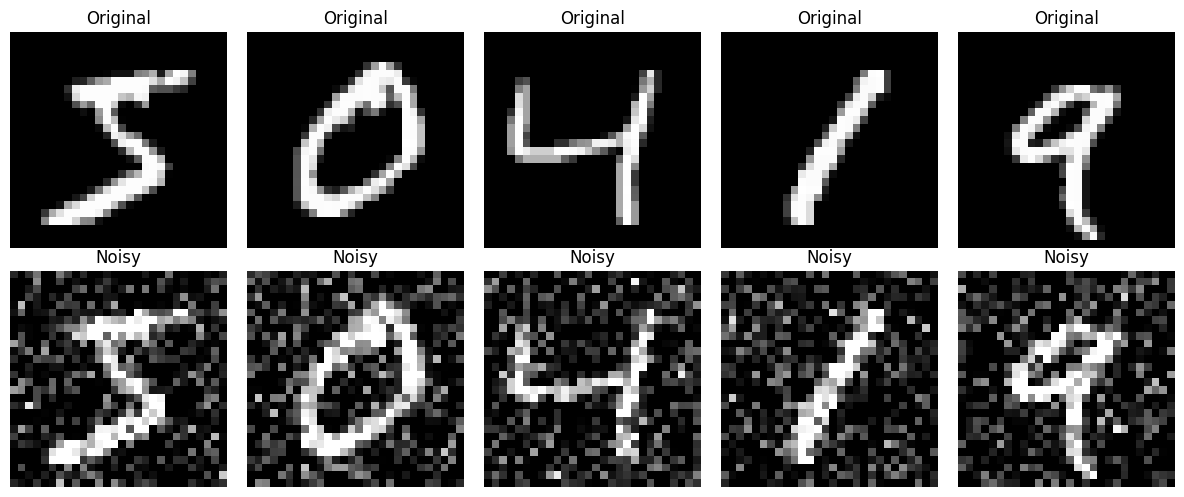

In [6]:
n = 5

plt.figure(figsize=(12, 5))

for i in range(n):
    # for original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # for noisy images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

The addition of Gaussian noise introduces random pixel variations across the images while preserving the overall digit structure. Although the handwritten digits remain recognizable, the increased background noise makes the reconstruction task more challenging. These noisy images are used as inputs, while the corresponding clean images serve as target outputs for training the denoising autoencoder.

## 5. Build the Denoising Autoencoder

A Convolutional Denoising Autoencoder is designed using an **encoder-decoder architecture**. The encoder learns compact feature representations from noisy input images, while the decoder reconstructs clean images from these learned features.

The architecture consists of the following components:

### Encoder
- **Conv2D (32 Filters):** Extracts low-level features such as edges and basic digit patterns.
- **Batch Normalization:** Normalizes feature maps to stabilize and accelerate training.
- **MaxPooling2D:** Reduces the spatial dimensions while preserving the most important features.
- **Conv2D (64 Filters):** Learns more complex and higher-level image features.
- **Batch Normalization:** Improves training stability.
- **MaxPooling2D:** Produces a compact latent representation of the input image.

### Decoder
- **Conv2D (64 Filters):** Begins reconstructing image features from the latent representation.
- **UpSampling2D:** Increases the spatial dimensions of the feature maps.
- **Conv2D (32 Filters):** Refines the reconstructed image.
- **UpSampling2D:** Restores the feature map to the original image size.
- **Conv2D (1 Filter, Sigmoid Activation):** Produces the final denoised grayscale image with pixel values in the range **[0,1]**.

Finally, the encoder and decoder are combined to form the complete denoising autoencoder model.

In [7]:
input_img = layers.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(inputs=input_img, outputs=decoded)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,881 (292.50 KB)

 Trainable params: 74,689 (291.75 KB)

 Non-trainable params: 192 (768.00 B)

### Model Summary

The model summary confirms that the denoising autoencoder follows a symmetric encoder-decoder architecture.

- The encoder progressively compresses the input image from **28 × 28** to a compact **7 × 7** feature representation.
- The decoder then reconstructs the compressed representation back to the original **28 × 28** image dimensions.
- The final output layer uses **sigmoid activation** to produce normalized pixel values in the range **[0, 1]**.

## 6. Compile and Configure Training

The autoencoder is compiled using the **Adam** optimizer and **Mean Squared Error (MSE)** loss function. To improve the training process and achieve better convergence, two callbacks are also configured.

### Training Configuration

- **Optimizer (Adam):** Updates the model weights efficiently using adaptive learning rates, resulting in faster and more stable convergence.
- **Loss Function (MSE):** Measures the difference between the reconstructed image and the original image by computing the average squared pixel-wise error.
- **EarlyStopping:** Monitors the validation loss and stops training if no further improvement is observed for a specified number of epochs. The best-performing model weights are restored automatically.

In [8]:
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

In [9]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

## 7. Train the Model

In [10]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stopping]
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 0.0145 - val_loss: 0.0134
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0068 - val_loss: 0.0067
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0061 - val_loss: 0.0063
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0058 - val_loss: 0.0061
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0055 - val_loss: 0.0059
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0054 - val_loss: 0.0058
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0052 - val_loss: 0.0057
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0051 - val_loss: 0.0056
Epoch 9/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0051 - val_loss: 0.0055
Epoch 10/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0050 - val_loss: 0.0054
Epoch 11/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0049 - val_loss: 0.0054
Epoch 12/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/st

### Training Observation

- Both the training and validation loss decreased rapidly during the initial epochs, indicating that the model quickly learned meaningful features from the noisy input images.
- The loss curves gradually stabilized as training progressed, demonstrating successful convergence of the denoising autoencoder.
- The validation loss remained consistently close to the training loss throughout training, suggesting good generalization with no significant signs of overfitting.
- The model achieved a final **training loss of 0.0045** and **validation loss of 0.0051**, demonstrating effective reconstruction of clean handwritten digit images from noisy inputs.

## 8. Generate Denoised Images

In [11]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


## 9. Reconstruction Results

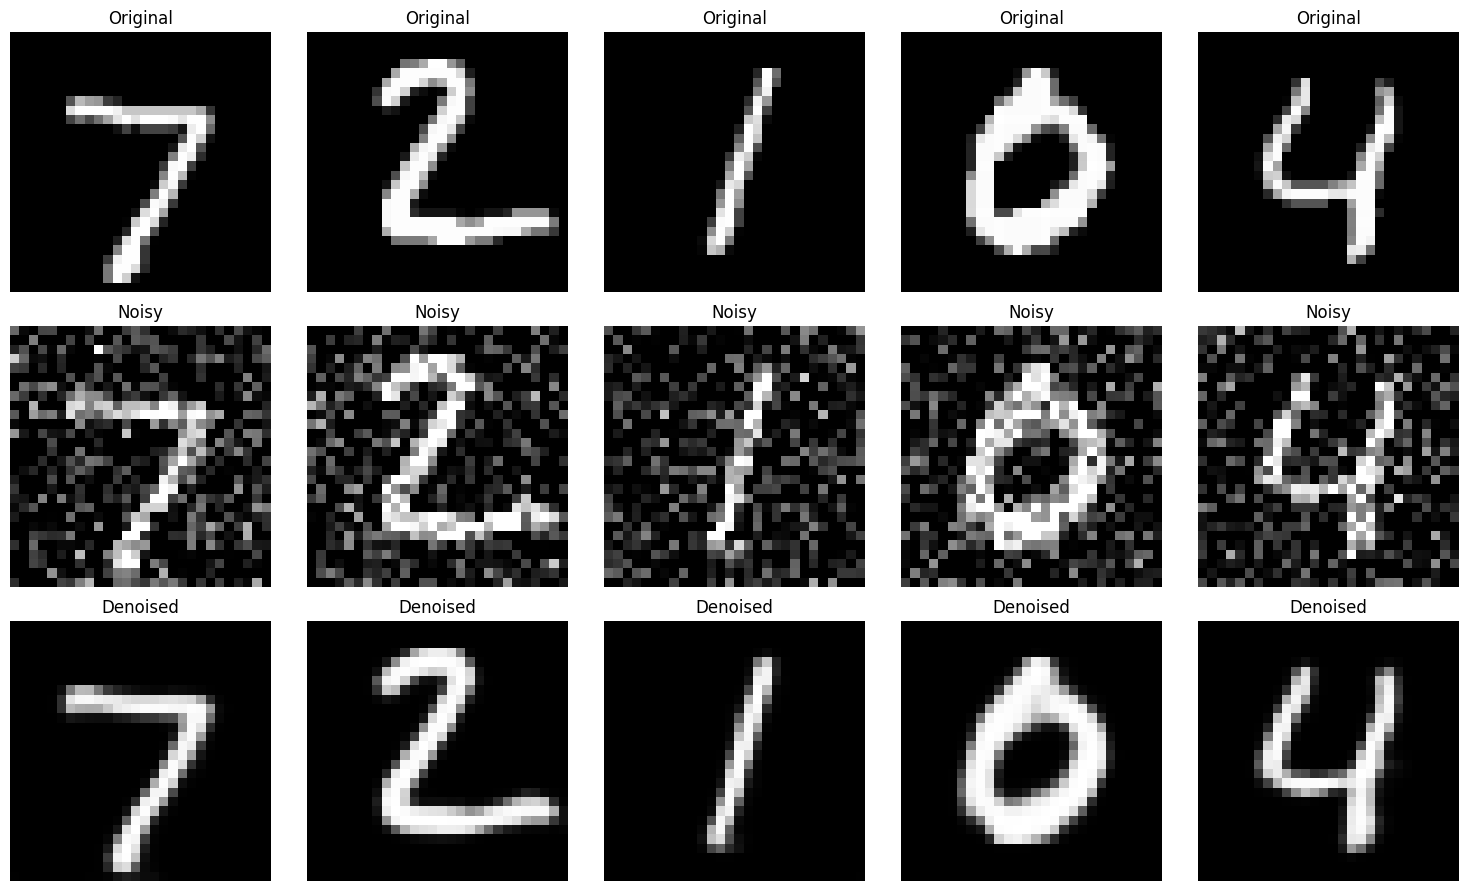

In [12]:
n = 5

plt.figure(figsize=(15, 9))

for i in range(n):
    # Original Image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised Image
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

The trained denoising autoencoder successfully reconstructed the handwritten digits from noisy input images. Although the input images contain significant Gaussian noise, the reconstructed outputs preserve the overall digit shapes while removing most of the background noise. A slight smoothing effect is observed in the reconstructed images, but the digits remain clear and easily recognizable, demonstrating the model's ability to learn meaningful image representations for denoising.

## 10. Plot Training and Validation Loss

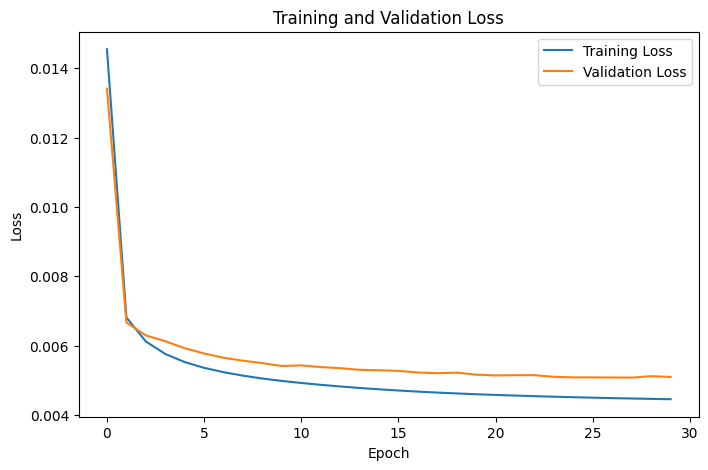

In [13]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Observation

- Both the training and validation loss decreased rapidly during the initial epochs, indicating that the model quickly learned meaningful features from the noisy input images.
- The loss curves gradually stabilized as training progressed, demonstrating successful convergence of the denoising autoencoder.
- The validation loss remained consistently close to the training loss throughout training, suggesting good generalization with no significant signs of overfitting.
- The final training loss (**0.0045**) and validation loss (**0.0051**) indicate that the model effectively learned to reconstruct clean handwritten digit images from noisy inputs.

## 11. Experiment: Noise Factor Comparison

An additional experiment was conducted to evaluate how the level of Gaussian noise affects the denoising performance of the autoencoder.

The experiment was designed as follows:

- **Objective:** To analyze the impact of different noise levels on image reconstruction quality.
- **Variable Changed:** The Gaussian noise factor was reduced from **0.3** to **0.2**.
- **Constant Parameters:** The model architecture and all training settings remained unchanged to ensure a fair comparison.
- **Evaluation:** The reconstruction quality was compared using the generated images and the final training and validation loss values.

### 11.1 Generate Noisy Images (Noise Factor = 0.2)

In [14]:
noise_factor_exp = 0.2

x_train_noisy_exp = x_train + noise_factor_exp * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy_exp = x_test + noise_factor_exp * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy_exp = np.clip(x_train_noisy_exp, 0., 1.)
x_test_noisy_exp = np.clip(x_test_noisy_exp, 0., 1.)

### 11.2 Build the Denoising Autoencoder

In [15]:
input_img = layers.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder_exp = models.Model(inputs=input_img, outputs=decoded)

### 11.3 Compile and Configure Training

In [16]:
autoencoder_exp.compile(
    optimizer='adam',
    loss='mse'
)

### 11.4 Train the Model

In [17]:
history_exp = autoencoder_exp.fit(
    x_train_noisy_exp,
    x_train,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stopping]
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0144 - val_loss: 0.0160
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0050 - val_loss: 0.0049
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0043 - val_loss: 0.0044
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0040 - val_loss: 0.0041
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0038 - val_loss: 0.0039
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0036 - val_loss: 0.0038
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0035 - val_loss: 0.0036
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0034 - val_loss: 0.0035
Epoch 9/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0033 - val_loss: 0.0035
Epoch 10/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0033 - val_loss: 0.0034
Epoch 11/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0032 - val_loss: 0.0034
Epoch 12/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/st

### Training Observation

- Both the training and validation loss decreased rapidly during the initial epochs, indicating effective learning from the noisy input images.
- The loss curves gradually stabilized as training progressed, demonstrating successful convergence of the denoising autoencoder.
- The validation loss remained consistently close to the training loss throughout training, indicating good generalization with no significant signs of overfitting.
- The model achieved a final **training loss of 0.0028** and **validation loss of 0.0031**, demonstrating improved reconstruction performance compared to the experiment with a **noise factor of 0.3**.

In [18]:
decoded_imgs_exp = autoencoder_exp.predict(x_test_noisy_exp)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


### 11.5 Reconstruction Results (Noise Factor = 0.2)

The trained autoencoder is evaluated on the noisy test images generated using a **Gaussian noise factor of 0.2**. The reconstructed outputs are compared with the original and noisy images to assess the denoising performance under lower input corruption.

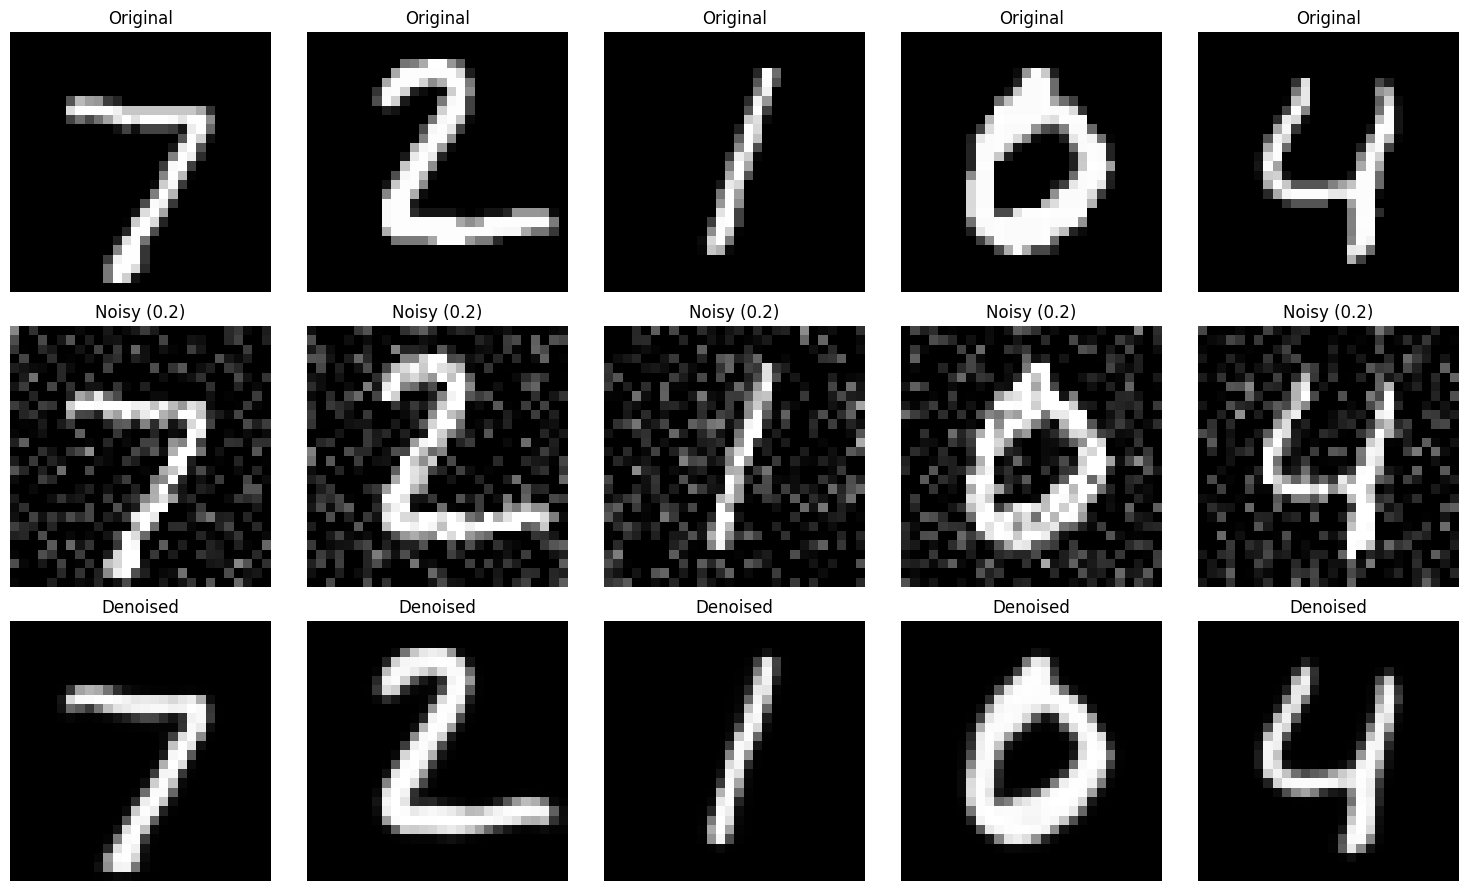

In [19]:
n = 5

plt.figure(figsize=(15, 9))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy (0.2)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy_exp[i].squeeze(), cmap='gray')
    plt.title("Noisy (0.2)")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs_exp[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

- The autoencoder successfully reconstructed clean handwritten digits from the noisy input images generated using a **noise factor of 0.2**.
- Although Gaussian noise is clearly visible in the input images, the reconstructed outputs effectively remove most of the background noise while preserving the overall digit shapes.
- The reconstructed digits closely resemble the original images, with only a slight smoothing effect observed in some digits, which is expected in image reconstruction tasks.
- The lower level of input noise made the reconstruction task less challenging, resulting in cleaner outputs and lower reconstruction loss compared to the **0.3 noise factor** experiment.

### 11.6 Comparative Visualization

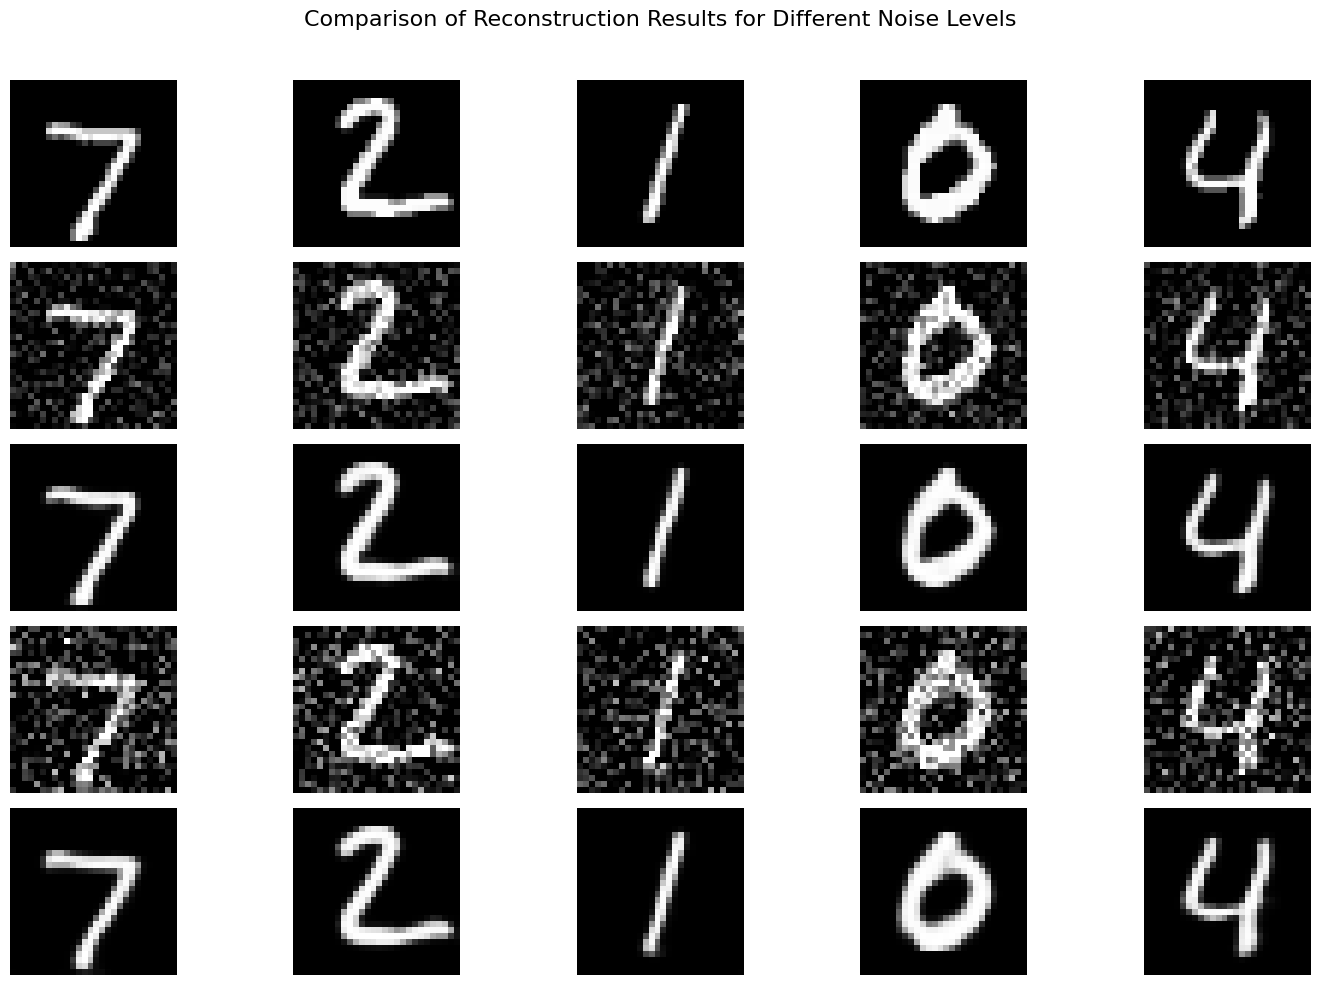

In [20]:
n = 5

fig, axes = plt.subplots(5, n, figsize=(15, 10))

row_labels = [
    "Original",
    "Noisy (0.2)",
    "Denoised (0.2)",
    "Noisy (0.3)",
    "Denoised (0.3)"
]

for i in range(n):
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[1, i].imshow(x_test_noisy_exp[i].squeeze(), cmap='gray')
    axes[2, i].imshow(decoded_imgs_exp[i].squeeze(), cmap='gray')
    axes[3, i].imshow(x_test_noisy[i].squeeze(), cmap='gray')
    axes[4, i].imshow(decoded_imgs[i].squeeze(), cmap='gray')

    for r in range(5):
        axes[r, i].axis('off')

for r in range(5):
    axes[r, 0].set_ylabel(
        row_labels[r],
        rotation=0,
        labelpad=45,
        fontsize=11,
        va='center'
    )

plt.suptitle(
    "Comparison of Reconstruction Results for Different Noise Levels",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 11.7 Comparative Analysis: Noise Factor (0.2 vs 0.3)

The denoising autoencoder was evaluated using two Gaussian noise levels while keeping the model architecture and training configuration unchanged. The comparison below summarizes the impact of the noise factor on reconstruction performance.

| Noise Factor | Training Loss | Validation Loss | Observation |
|--------------|--------------:|----------------:|-------------|
| **0.2** | **0.0028** | **0.0031** | Better reconstruction with sharper digit boundaries and lower reconstruction error. |
| **0.3** | **0.0045** | **0.0051** | More challenging denoising task with slightly blurrier reconstructed images due to higher input corruption. |

### Key Findings

- Reducing the Gaussian noise factor from **0.3** to **0.2** improved both the visual reconstruction quality and the reconstruction loss.
- The model trained with **0.2** produced cleaner and slightly sharper reconstructed digits while preserving their overall structure.
- Despite the higher noise level, the model trained with **0.3** successfully reconstructed recognizable handwritten digits, demonstrating the robustness of the denoising autoencoder.

## Conclusion

In this assignment, a Convolutional Denoising Autoencoder was successfully implemented and trained on the MNIST dataset to reconstruct clean handwritten digit images from noisy inputs.

The model demonstrated stable training, achieved low reconstruction loss, and effectively removed Gaussian noise while preserving the essential structure of handwritten digits. The training and validation loss curves indicated good convergence with no significant signs of overfitting.

A comparative experiment using Gaussian noise factors of **0.3** and **0.2** showed that reducing the amount of input noise improved both the reconstruction quality and the reconstruction loss. While the model trained with **0.2** produced cleaner reconstructions, the model trained with **0.3** also recovered recognizable handwritten digits, demonstrating that the denoising autoencoder performs effectively across different levels of Gaussian noise.